# Customer Churn Prediction

## Exploratory Data Analysis (EDA)

**Author:** Shraddha D S

**Goal:**
To analyze the customer churn dataset, understand its features, identify data quality issues, and prepare the data for machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("../data/customer_churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
print("Dataset Shape:",df.shape)

Dataset Shape: (7043, 21)


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

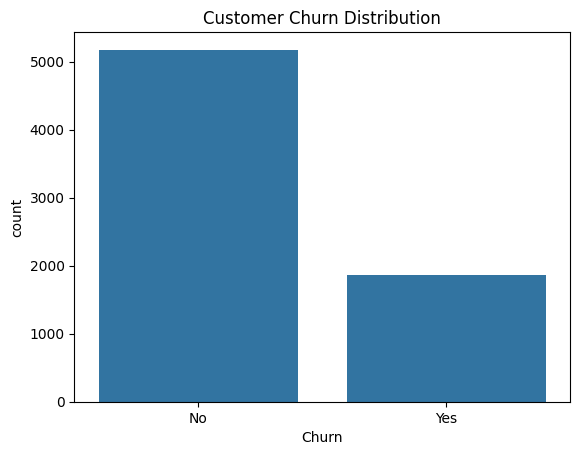

In [13]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

Gender vs Churn

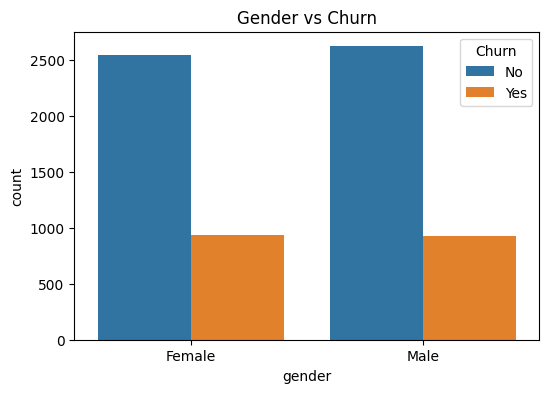

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.show()

Contract vs Churn

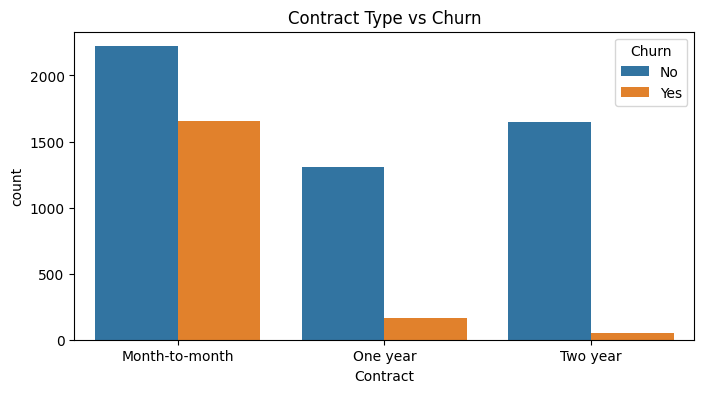

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

Internet Service vs Churn

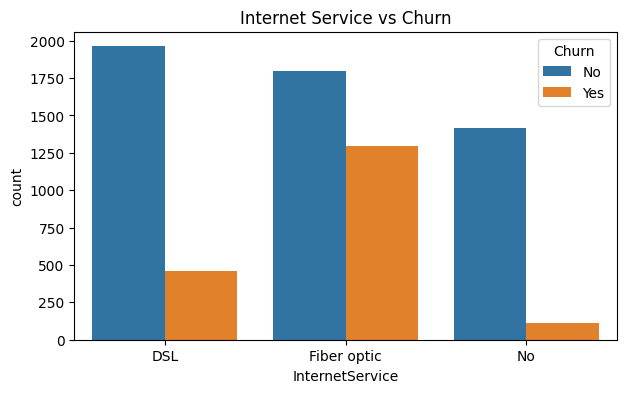

In [16]:
plt.figure(figsize=(7,4))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

Senior Citizen vs Churn

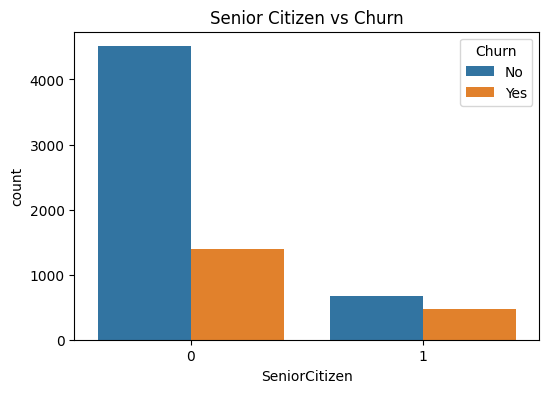

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

Monthly Charges Distribution

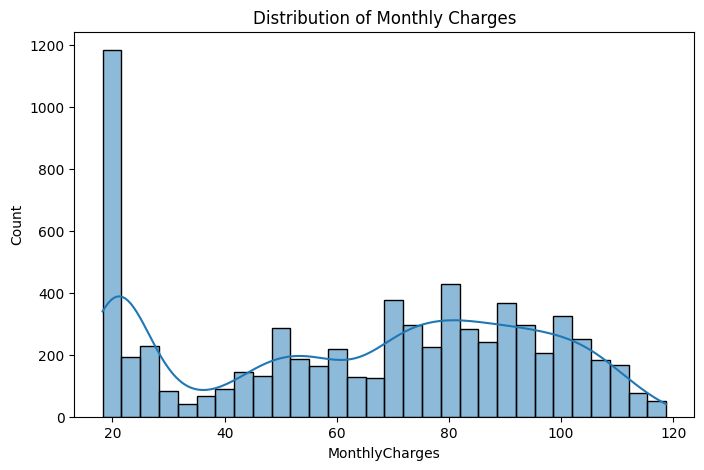

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

## Observation

- MonthlyCharges ranges from approximately 18 to 120.
- Most customers pay around 20 per month.
- Another large group pays between 70 and 100.
- The distribution is not perfectly normal.

Contract Type vs Churn

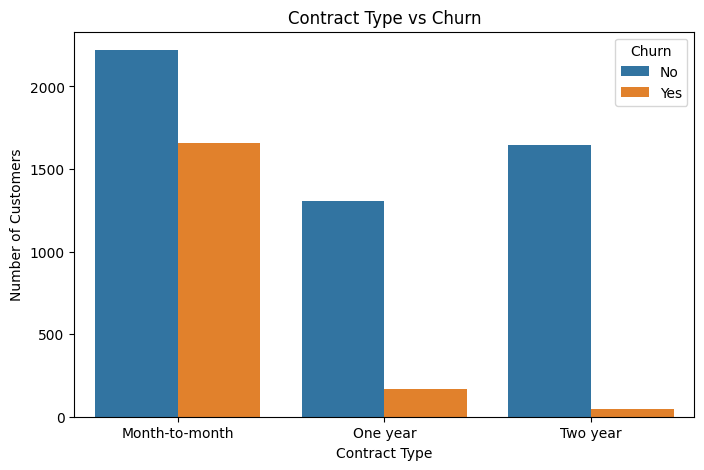

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Customers with Month-to-Month contracts have the highest churn rate.
- Customers with One-Year and Two-Year contracts are much less likely to churn.
- Long-term contracts improve customer retention.

Payment Method vs Churn

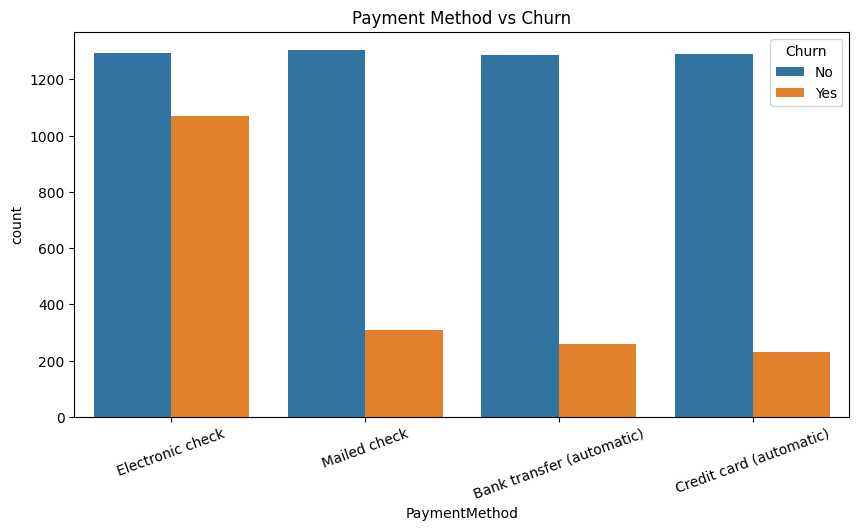

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")
plt.show()

### Observation

- Customers using Electronic Check have the highest churn.
- Customers using automatic payment methods have lower churn.
- Encouraging automatic payments may improve customer retention.

Internet Service vs Churn


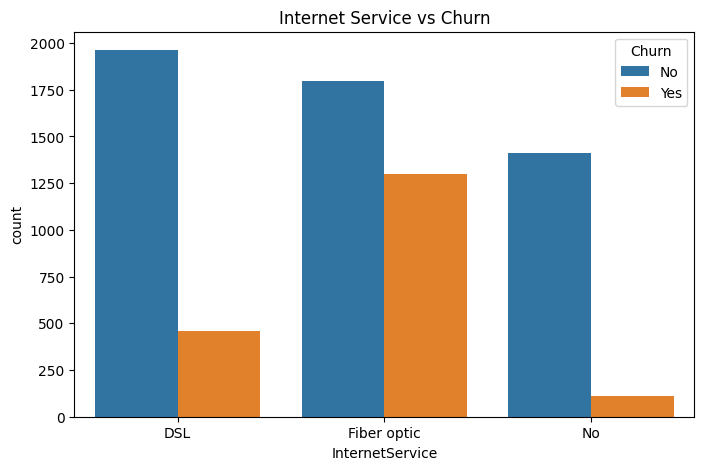

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Churn")
plt.show()

Tenure Distribution

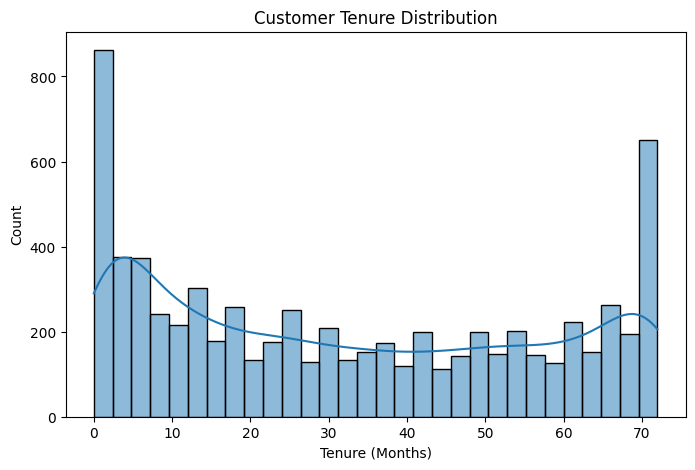

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.show()

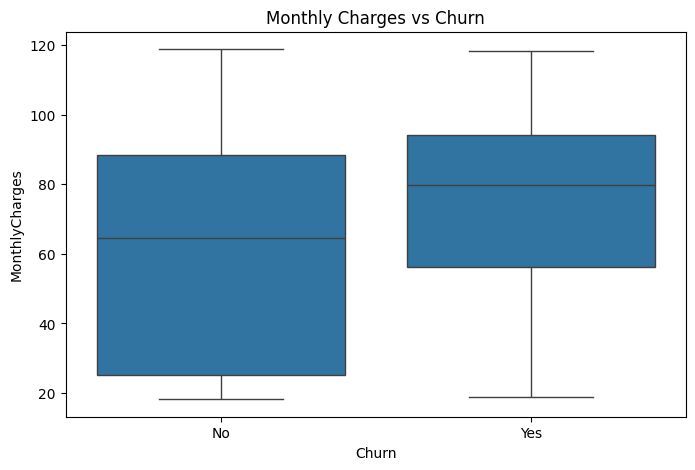

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

### Observation

- Customers who churn tend to have higher monthly charges.
- Higher subscription costs may contribute to customer churn.
- The company can reduce churn by offering discounts or better-value plans to high-paying customers.

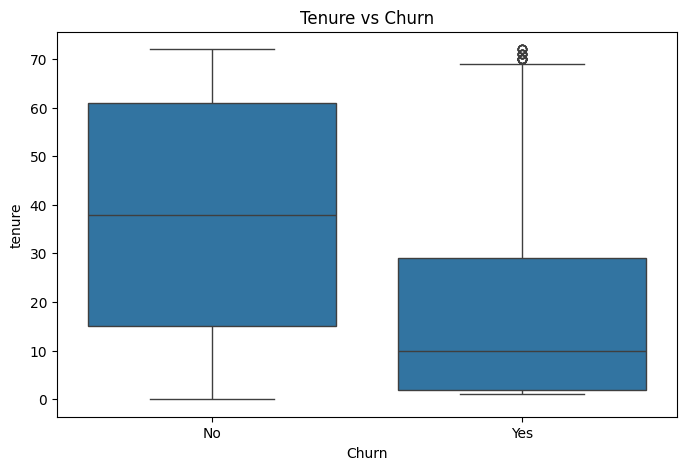

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.show()

### Observation

- Customers with low tenure have a higher churn rate.
- Long-term customers are more loyal.
- Improving the onboarding experience and early customer engagement may reduce churn.

# Final EDA Summary

## Key Findings

1. The dataset contains 7043 customer records and 21 features.
2. No missing values were found.
3. The dataset is imbalanced:
   - No Churn: 5174
   - Churn: 1869
4. Month-to-month contract customers have the highest churn.
5. Electronic check users have the highest churn.
6. Customers with higher monthly charges tend to churn more.
7. Customers with low tenure are more likely to churn.
8. Long-term contracts improve customer retention.